<a href="https://colab.research.google.com/github/celalthedon/cnn-experiments/blob/main/MiniViT_CIFAR10_Vision_Transformer_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [7]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [8]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


In [9]:
train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

In [10]:
batch_size = 64

In [11]:
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [12]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10])

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Labels example: tensor([6, 3, 1, 0, 1, 3, 3, 1, 1, 8])


In [13]:
class_names= train_dataset.classes
class_names.__len__()

10

In [14]:
img_size = 32
patch_size = 4
in_channels = 3
num_classes = 10

embed_dim = 128
depth = 4
num_heads = 4
mlp_dim = 256
dropout = 0.1

In [15]:
import torch.nn as nn

In [16]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()

        assert img_size % patch_size == 0

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

patch_embed = PatchEmbedding(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=128
).to(device)

patch_tokens = patch_embed(images)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Patch tokens shape:", patch_tokens.shape)
print("Number of patches:", patch_embed.num_patches)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Patch tokens shape: torch.Size([64, 64, 128])
Number of patches: 64


#adding a cls token and positional embedding

In [20]:
class MiniViTEmbedding(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        embed_dim=128,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.patch_embed(x)
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        return x

In [21]:
embedding_layer = MiniViTEmbedding(
    img_size=32,
    patch_size=4,
    in_channels = 3,
    embed_dim=128,
    dropout=0.1
).to(device)

tokens = embedding_layer(images)

In [22]:
print("Images shape:", images.shape)
print("Tokens shape:", tokens.shape)
print("CLS token shape:", embedding_layer.cls_token.shape)
print("Pos embedding shape:", embedding_layer.pos_embed.shape)

Images shape: torch.Size([64, 3, 32, 32])
Tokens shape: torch.Size([64, 65, 128])
CLS token shape: torch.Size([1, 1, 128])
Pos embedding shape: torch.Size([1, 65, 128])


In [24]:
class MiniViTBackbone(nn.Module):
  def __init__(
      self,
      img_size =  32,
      patch_size = 4,
      in_channels = 3,
      embed_dim = 128,
      depth = 4,
      num_heads = 4,
      mlp_dim = 256,
      dropout = 0.1
  ):
    super().__init__()

    self.embedding = MiniViTEmbedding(
        img_size=img_size,
        patch_size=patch_size,
        in_channels=in_channels,
        embed_dim=embed_dim,
        dropout=dropout
    )

    encoder_layer = nn.TransformerEncoderLayer(
        d_model=embed_dim,
        nhead=num_heads,
        dim_feedforward=mlp_dim,
        dropout=dropout,
        activation="gelu",
        batch_first=True,
        norm_first=True
    )

    self.encoder = nn.TransformerEncoder(
        encoder_layer=encoder_layer,
        num_layers=depth
    )

  def forward(self, x):
    x = self.embedding(x)
    x = self.encoder(x)
    return x

In [25]:
backbone = MiniViTBackbone(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=128,
    depth=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1
).to(device)

/tmp/ipykernel_656/4184372814.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [28]:
encoded_tokens.shape

torch.Size([64, 65, 128])

In [29]:
encoded_tokens = backbone(images)

In [30]:
print("Input images shape:", images.shape)
print("Encoded tokens shape:", encoded_tokens.shape)

Input images shape: torch.Size([64, 3, 32, 32])
Encoded tokens shape: torch.Size([64, 65, 128])


In [31]:
cls_output = encoded_tokens[:, 0]

print("CLS output shape:", cls_output.shape)

CLS output shape: torch.Size([64, 128])


In [32]:
cls_output

tensor([[-1.8348, -1.4395,  0.4039,  ...,  2.1372,  0.9628, -1.2943],
        [-1.8868, -0.8881,  0.6138,  ...,  1.6274, -1.3780, -1.9953],
        [-1.8147,  1.9142,  0.0671,  ...,  1.9215, -0.3200, -2.3493],
        ...,
        [-1.4703, -0.7877,  0.8476,  ...,  1.9464, -0.1821, -1.3304],
        [-0.4095,  0.1732, -1.0351,  ...,  1.2135, -1.3862, -3.4230],
        [-1.8838, -0.8048, -0.3577,  ...,  2.3651, -1.9460, -2.2583]],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [35]:
class MiniViT(nn.Module):
  def __init__(
      self,
      img_size=32,
      patch_size=4,
      in_channels=3,
      num_classes=10,
      embed_dim=128,
      depth=4,
      num_heads=4,
      mlp_dim=256,
      dropout=0.1
  ):
    super().__init__()
    self.backbone = MiniViTBackbone(
        img_size=img_size,
        patch_size=patch_size,
        in_channels=in_channels,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_dim=mlp_dim,
        dropout=dropout
      )

    self.norm = nn.LayerNorm(embed_dim)
    self.fc = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.backbone(x)
    cls_token = x[:,0]
    cls_token = self.norm(cls_token)
    logits = self.fc(cls_token)
    return logits

In [36]:
model = MiniViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=128,
    depth=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1
).to(device)

/tmp/ipykernel_656/4184372814.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [37]:
logits = model(images)

print("Input images shape:", images.shape)
print("Logits shape:", logits.shape)

Input images shape: torch.Size([64, 3, 32, 32])
Logits shape: torch.Size([64, 10])


In [38]:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, labels)

In [39]:
preds = logits.argmax(dim=1)

print("Predictions shape:", preds.shape)
print("Predictions example:", preds[:10])
print("Labels example:", labels[:10])

Predictions shape: torch.Size([64])
Predictions example: tensor([5, 3, 3, 3, 4, 3, 3, 3, 3, 6], device='cuda:0')
Labels example: tensor([4, 6, 5, 4, 2, 5, 7, 0, 1, 8], device='cuda:0')


#full forward

In [40]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

logits = model(images)

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, labels)

print(loss)

tensor(2.4725, device='cuda:0', grad_fn=<NllLossBackward0>)


#detailed forward

In [56]:
class MiniViT(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=4,
        num_heads=4,
        mlp_dim=256,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, print_shapes=False):
        if print_shapes:
            print("Input image:", x.shape)
        x = self.patch_embed(x)
        if print_shapes:
            print("After PatchEmbedding:", x.shape)
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        if print_shapes:
            print("CLS tokens:", cls_tokens.shape)
        x = torch.cat([cls_tokens, x], dim=1)
        if print_shapes:
            print("After adding CLS token:", x.shape)
        x = x + self.pos_embed
        if print_shapes:
            print("After positional embedding:", x.shape)
        x = self.dropout(x)
        x = self.encoder(x)
        if print_shapes:
            print("After Transformer Encoder:", x.shape)
        cls_output = x[:, 0]
        if print_shapes:
            print("CLS output:", cls_output.shape)
        cls_output = self.norm(cls_output)
        logits = self.head(cls_output)
        if print_shapes:
            print("Logits:", logits.shape)

        return logits

In [42]:
model = MiniViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=128,
    depth=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1
).to(device)

/tmp/ipykernel_656/3271513558.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [43]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

logits = model(images, print_shapes=True)

Input image: torch.Size([64, 3, 32, 32])
After PatchEmbedding: torch.Size([64, 64, 128])
CLS tokens: torch.Size([64, 1, 128])
After adding CLS token: torch.Size([64, 65, 128])
After positional embedding: torch.Size([64, 65, 128])
After Transformer Encoder: torch.Size([64, 65, 128])
CLS output: torch.Size([64, 128])
Logits: torch.Size([64, 10])


In [44]:
loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(logits, labels)

print("Labels shape:", labels.shape)
print("Loss:", loss.item())

Labels shape: torch.Size([64])
Loss: 2.3422911167144775


In [45]:
preds = logits.argmax(dim=1)

print("Preds shape:", preds.shape)
print("Preds example:", preds[:10])
print("Labels example:", labels[:10])

Preds shape: torch.Size([64])
Preds example: tensor([7, 7, 2, 2, 7, 2, 7, 7, 7, 7], device='cuda:0')
Labels example: tensor([3, 1, 6, 2, 4, 0, 3, 0, 0, 9], device='cuda:0')


In [46]:

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [47]:
def accuracy_fn(logits, labels):
    preds = logits.argmax(dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [53]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_acc = 0, 0

    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = accuracy_fn(logits, labels)

        total_loss += loss.item()
        total_acc += acc
    avg_loss = total_loss / len(train_loader)
    avg_acc = total_acc / len(train_loader)

    return avg_loss, avg_acc

In [54]:
def evaluate(model, test_loader, loss_fn, device):
    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)

            acc = accuracy_fn(logits, labels)

            total_loss += loss.item()
            total_acc += acc

    avg_loss = total_loss / len(test_loader)
    avg_acc = total_acc / len(test_loader)

    return avg_loss, avg_acc

In [57]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device
    )

    test_loss, test_acc = evaluate(
        model=model,
        test_loader=test_loader,
        loss_fn=loss_fn,
        device=device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/10] Train Loss: 1.3161 | Train Acc: 0.5271 | Test Loss: 1.3969 | Test Acc: 0.5132
Epoch [2/10] Train Loss: 1.3001 | Train Acc: 0.5354 | Test Loss: 1.4147 | Test Acc: 0.5142
Epoch [3/10] Train Loss: 1.2665 | Train Acc: 0.5459 | Test Loss: 1.3886 | Test Acc: 0.5234
Epoch [4/10] Train Loss: 1.2468 | Train Acc: 0.5505 | Test Loss: 1.4308 | Test Acc: 0.5010
Epoch [5/10] Train Loss: 1.2232 | Train Acc: 0.5568 | Test Loss: 1.3713 | Test Acc: 0.5303
Epoch [6/10] Train Loss: 1.1990 | Train Acc: 0.5706 | Test Loss: 1.3320 | Test Acc: 0.5493
Epoch [7/10] Train Loss: 1.1863 | Train Acc: 0.5717 | Test Loss: 1.3503 | Test Acc: 0.5322
Epoch [8/10] Train Loss: 1.1665 | Train Acc: 0.5795 | Test Loss: 1.3558 | Test Acc: 0.5410
Epoch [9/10] Train Loss: 1.1404 | Train Acc: 0.5884 | Test Loss: 1.3377 | Test Acc: 0.5396
Epoch [10/10] Train Loss: 1.1118 | Train Acc: 0.5986 | Test Loss: 1.3387 | Test Acc: 0.5361


#Real vs Predicted visualization

In [58]:
import matplotlib.pyplot as plt

In [59]:
def denormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    img = img.cpu() * std + mean
    img = img.clamp(0, 1)

    return img

In [60]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

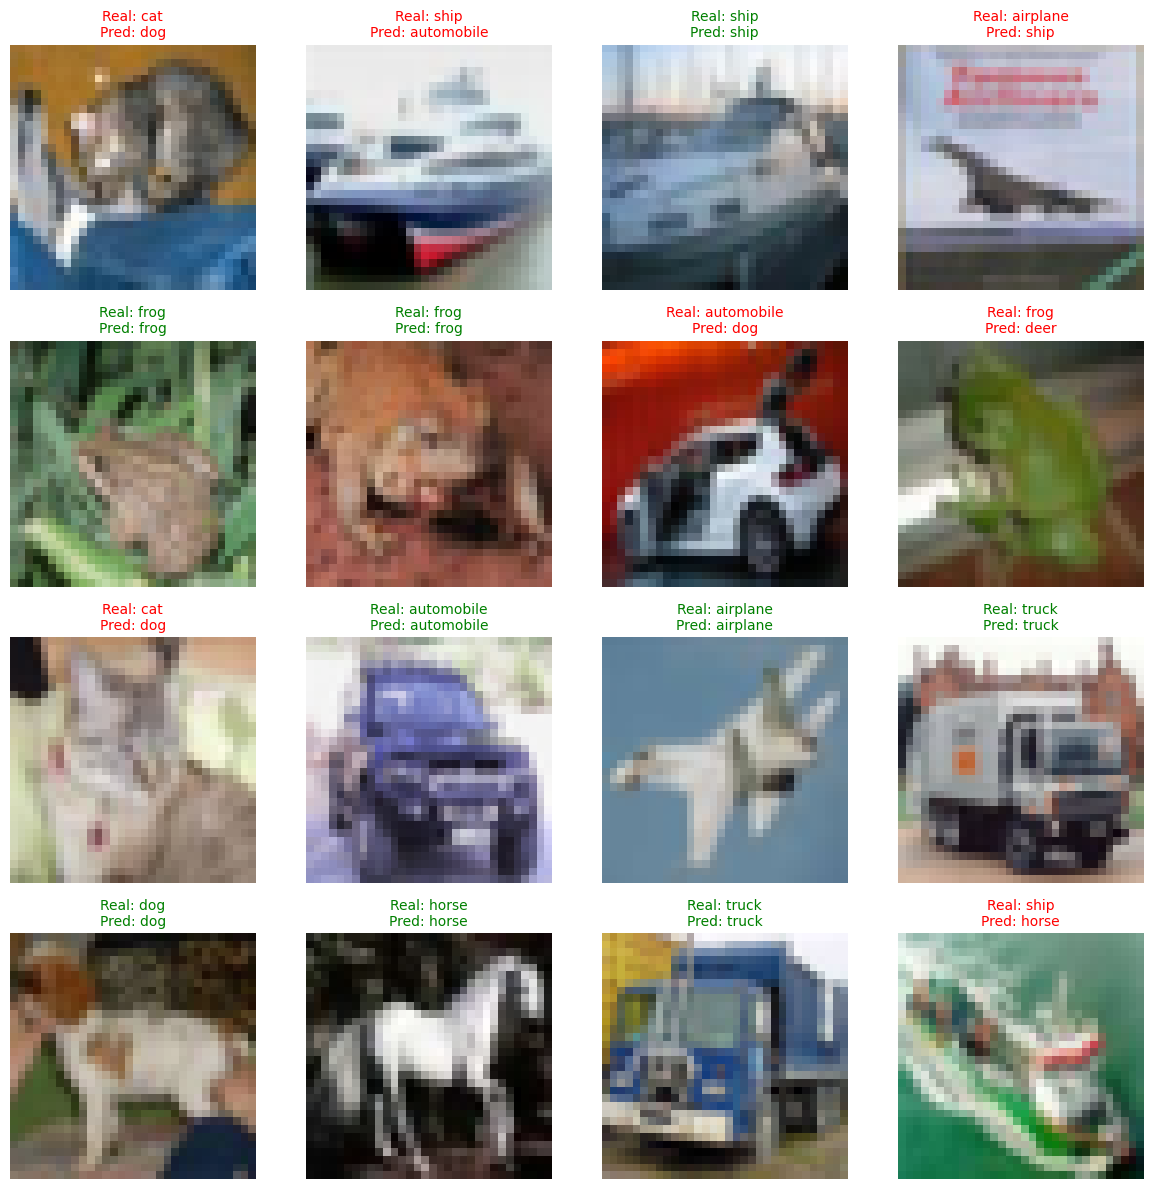

In [62]:
class_names = train_dataset.classes

num_images = 16

plt.figure(figsize=(12, 12))

for i in range(num_images):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)

    true_label = labels[i].item()
    pred_label = preds[i].item()

    true_name = class_names[true_label]
    pred_name = class_names[pred_label]

    is_correct = true_label == pred_label

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    title = f"Real: {true_name}\nPred: {pred_name}"

    if is_correct:
        plt.title(title, color="green", fontsize=10)
    else:
        plt.title(title, color="red", fontsize=10)

plt.tight_layout()
plt.show()